<a href="https://colab.research.google.com/github/Developer-Abnam/machine-learning-zoomcamp-2025-solutions/blob/main/BCGX_task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Starter

---

1. Import packages
2. Loading data with Pandas
3. Descriptive statistics of data
4. Data visualization

---

## 1. Import packages

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## 2. Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python.

In [11]:
client_df = pd.read_csv('/content/client_data (1).csv')
price_df = pd.read_csv('/content/price_data (1).csv')

Let's look at the first 3 rows of both dataframes to see what the data looks like

In [12]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2.0,678.99,3.0,lxidpiddsbxsbosboudacockeimpuepw,43.648,1.0
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1.0,18.89,6.0,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0.0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1.0,6.60,6.0,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0.0


With the client data, we have mix of numeric and categorical data, which we will need to transform before modelling later

In [13]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


With the price data, it is purely numeric but we will see alot of zeros.

---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

In [14]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4395 non-null   object 
 1   channel_sales                   4395 non-null   object 
 2   cons_12m                        4395 non-null   int64  
 3   cons_gas_12m                    4395 non-null   int64  
 4   cons_last_month                 4395 non-null   int64  
 5   date_activ                      4395 non-null   object 
 6   date_end                        4395 non-null   object 
 7   date_modif_prod                 4395 non-null   object 
 8   date_renewal                    4395 non-null   object 
 9   forecast_cons_12m               4395 non-null   float64
 10  forecast_cons_year              4395 non-null   int64  
 11  forecast_discount_energy        4395 non-null   float64
 12  forecast_meter_rent_12m         43

In [15]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11027 entries, 0 to 11026
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  11027 non-null  object 
 1   price_date          11027 non-null  object 
 2   price_off_peak_var  11026 non-null  float64
 3   price_peak_var      11026 non-null  float64
 4   price_mid_peak_var  11026 non-null  float64
 5   price_off_peak_fix  11026 non-null  float64
 6   price_peak_fix      11026 non-null  float64
 7   price_mid_peak_fix  11026 non-null  float64
dtypes: float64(6), object(2)
memory usage: 689.3+ KB


You can see that all of the `datetime` related columns are not currently in datetime format. We will need to convert these later.

### Statistics

Now let's look at some statistics about the datasets.

In [16]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,4.395000e+03,4.395000e+03,4395.000000,4395.000000,4395.000000,4395.000000,4395.000000,4395.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000,4394.000000
mean,1.734104e+05,3.205496e+04,17307.870080,1874.999295,1348.446871,0.858931,62.405322,0.137074,0.050256,43.078285,148.684137,24.637217,24.637217,1.291306,193.894734,5.010241,18.270919,0.101730
std,6.276237e+05,1.836407e+05,67743.119124,2294.124945,2734.517424,4.800824,66.317310,0.024294,0.048877,4.619333,313.601662,20.501484,20.501484,0.664389,428.023908,1.603869,13.723127,0.302327
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,3.300000,0.000000
25%,5.665500e+03,0.000000e+00,0.000000,488.605000,0.000000,0.000000,16.160000,0.116340,0.000000,40.606701,0.000000,14.335000,14.335000,1.000000,52.047500,4.000000,12.500000,0.000000
50%,1.439400e+04,0.000000e+00,757.000000,1135.230000,276.000000,0.000000,18.700000,0.143166,0.083909,44.311378,31.355000,21.685000,21.685000,1.000000,114.265000,5.000000,13.856000,0.000000
75%,4.110650e+04,0.000000e+00,3361.000000,2429.830000,1724.000000,0.000000,130.680000,0.146348,0.098837,44.311378,189.820000,29.850000,29.850000,1.000000,249.485000,6.000000,19.720000,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,61357.170000,63969.000000,30.000000,599.310000,0.273963,0.168092,59.266378,9682.890000,374.640000,374.640000,9.000000,24570.650000,13.000000,260.000000,1.000000


The describe method gives us a lot of information about the client data. The key point to take away from this is that we have highly skewed data, as exhibited by the percentile values.

In [17]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,11026.000000,11026.000000,11026.000000,11026.000000,11026.000000,11026.000000
mean,0.140397,0.054507,0.031165,43.053792,10.704504,6.608180
std,0.023916,0.050191,0.036644,5.296933,12.703790,7.858572
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125748,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.145924,0.085058,0.000000,44.266930,0.000000,0.000000
75%,0.151367,0.101673,0.072394,44.444710,24.437330,16.226389
max,0.279586,0.168256,0.114102,59.173468,36.490689,16.958222


Overall the price data looks good.

---

## 3. Data visualization

Now let's dive a bit deeper into the dataframes

In [18]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )


## Churn

In [27]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
churn_percentage

,Companies
churn,
0.0,89.827037
1.0,10.172963


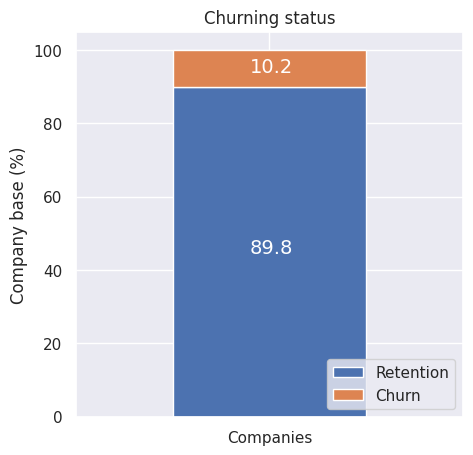

In [20]:
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

About 10% of the total customers have churned. (This sounds about right)

### Sales Channel

In [32]:
channel = client_df[['id', 'channel_sales', 'churn']]
channel = channel.groupby(['channel_sales', 'churn'])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
channel_churn.head()

churn,0.0,1.0
channel_sales,,
foosdfpfkusacimwkcsosbicdxkicaua,87.138584,12.861416
usilxuppasemubllopkaafesmlibmsdf,89.069767,10.930233
ewpakwlliwisiwduibdlfmalxowmwpci,91.416309,8.583691
MISSING,91.972077,8.027923
lmkebamcaaclubfxadlmueccxoimlema,94.764398,5.235602


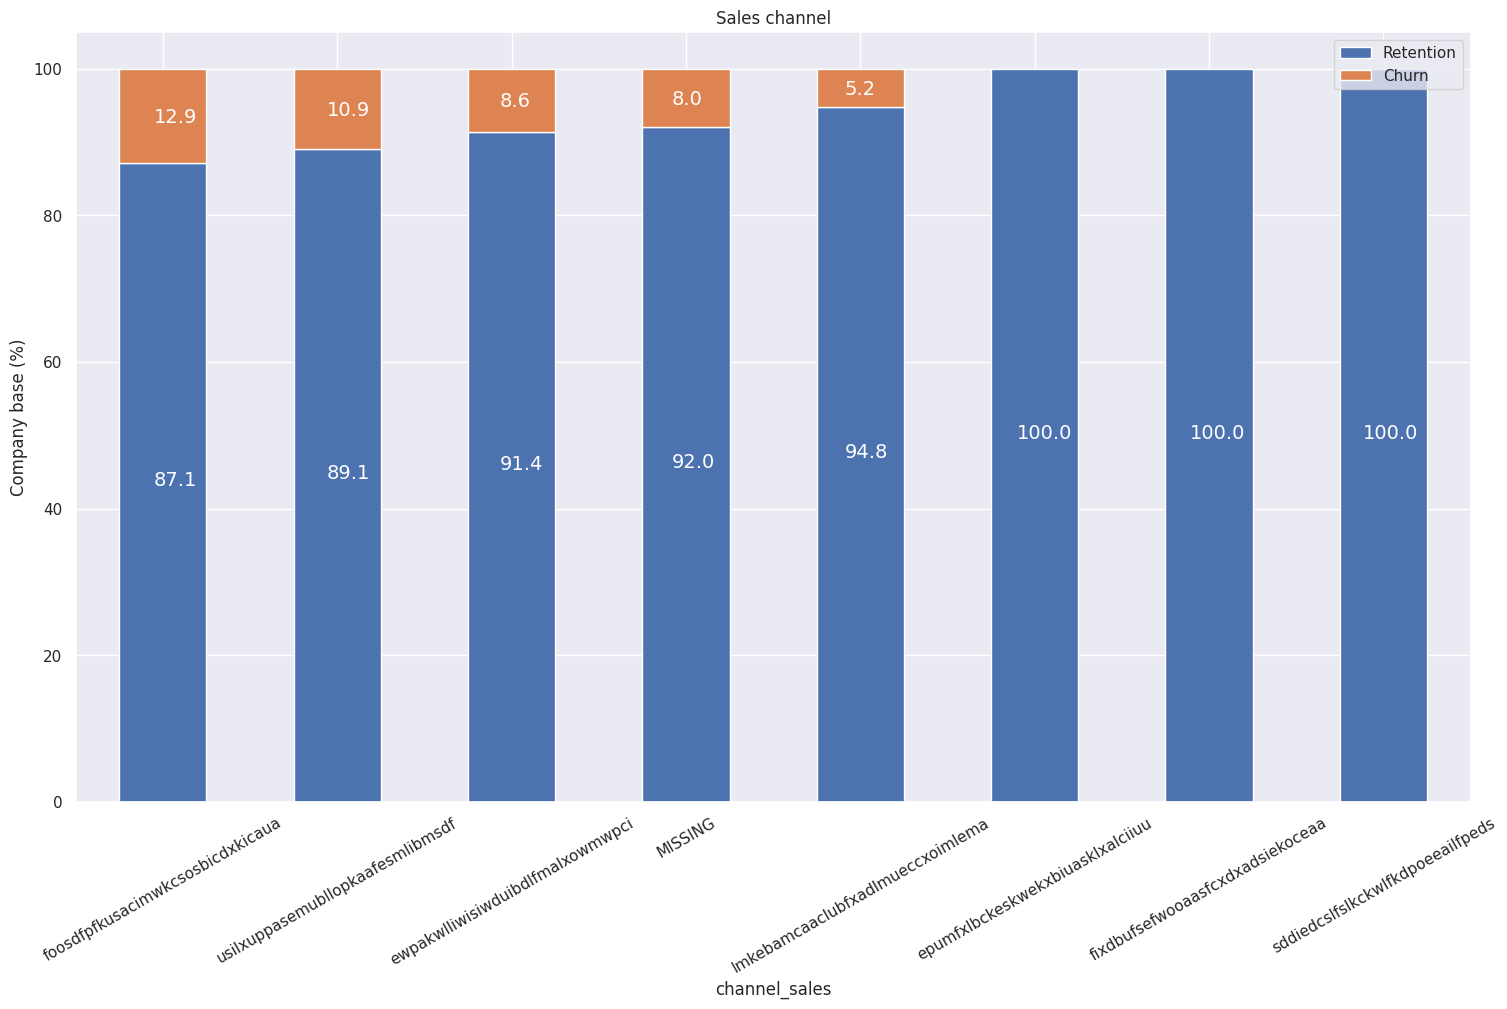

In [22]:
plot_stacked_bars(channel_churn, 'Sales channel', rot_=30)

Interestingly, the churning customers are distributed over 5 different values for `channel_sales`. As well as this, the value of `MISSING` has a churn rate of 7.6%. `MISSING` indicates a missing value and was added by the team when they were cleaning the dataset. This feature could be an important feature when it comes to building our model.


### Consumption
Let's see the distribution of the consumption in the last year and month. Since the consumption data is univariate, let use histogram to visualize their data distribution.

In [23]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [24]:
def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe['churn']==0][column], "Churn": dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[['Retention', 'Churn']].plot(kind="hist", ax=ax, bins=bins_, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

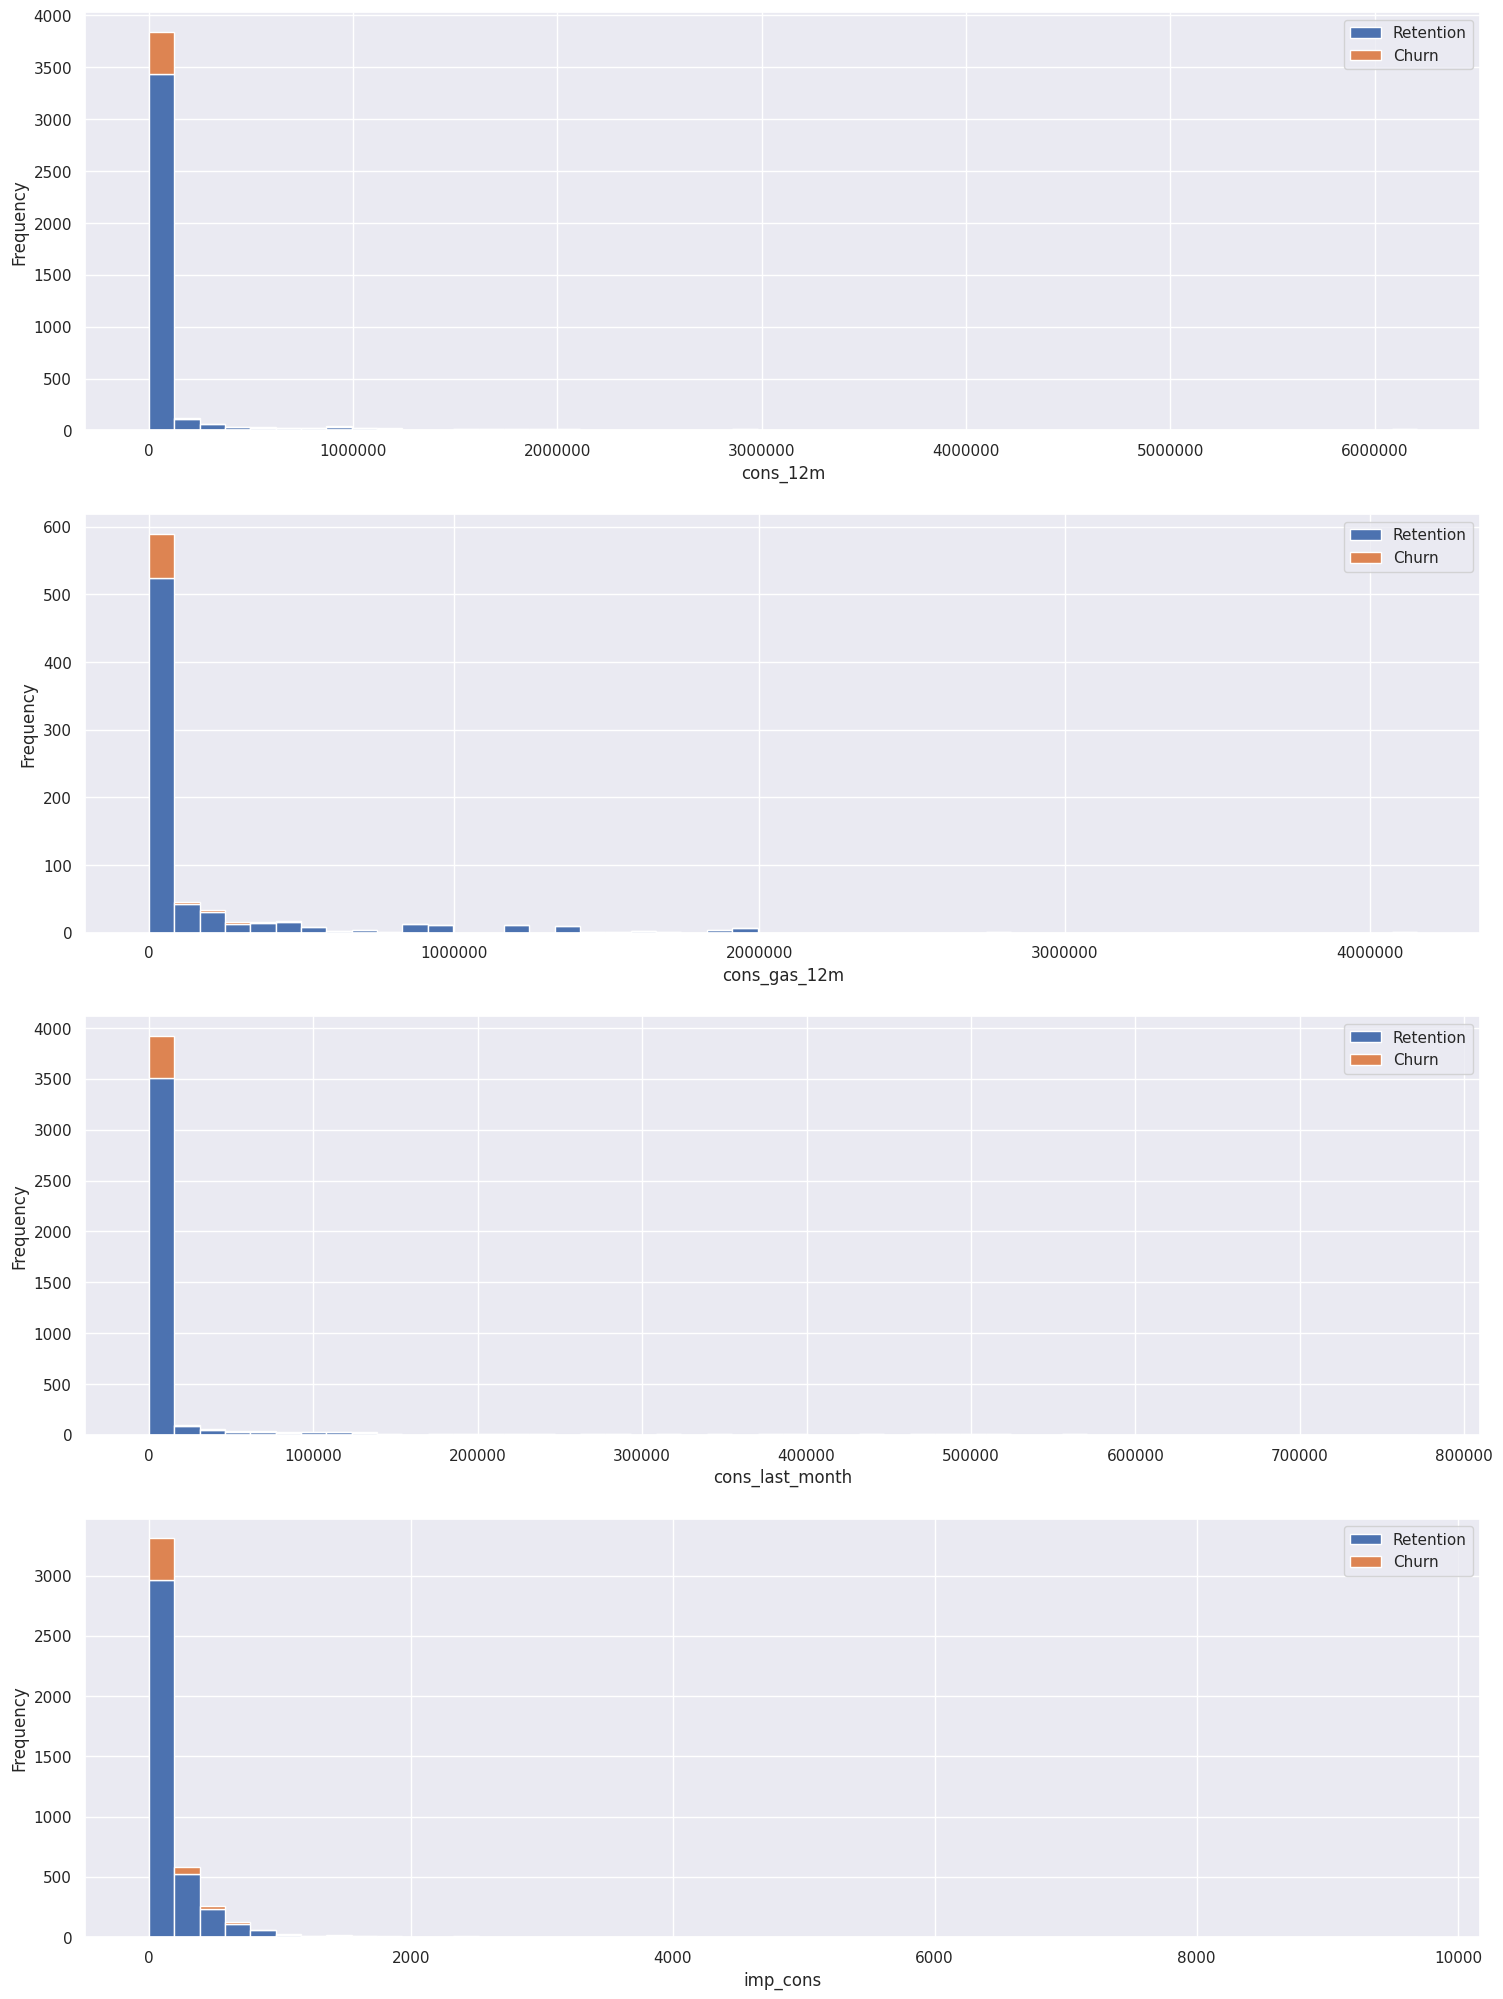

In [25]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])

Clearly, the consumption data is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution. The values on the higher and lower end of the distribution are likely to be outliers. We can use a standard plot to visualise the outliers in more detail. A boxplot is a standardized way of displaying the distribution based on a five number summary:
- Minimum
- First quartile (Q1)
- Median
- Third quartile (Q3)
- Maximum

It can reveal outliers and what their values are. It can also tell us if our data is symmetrical, how tightly our data is grouped and if/how our data is skewed.

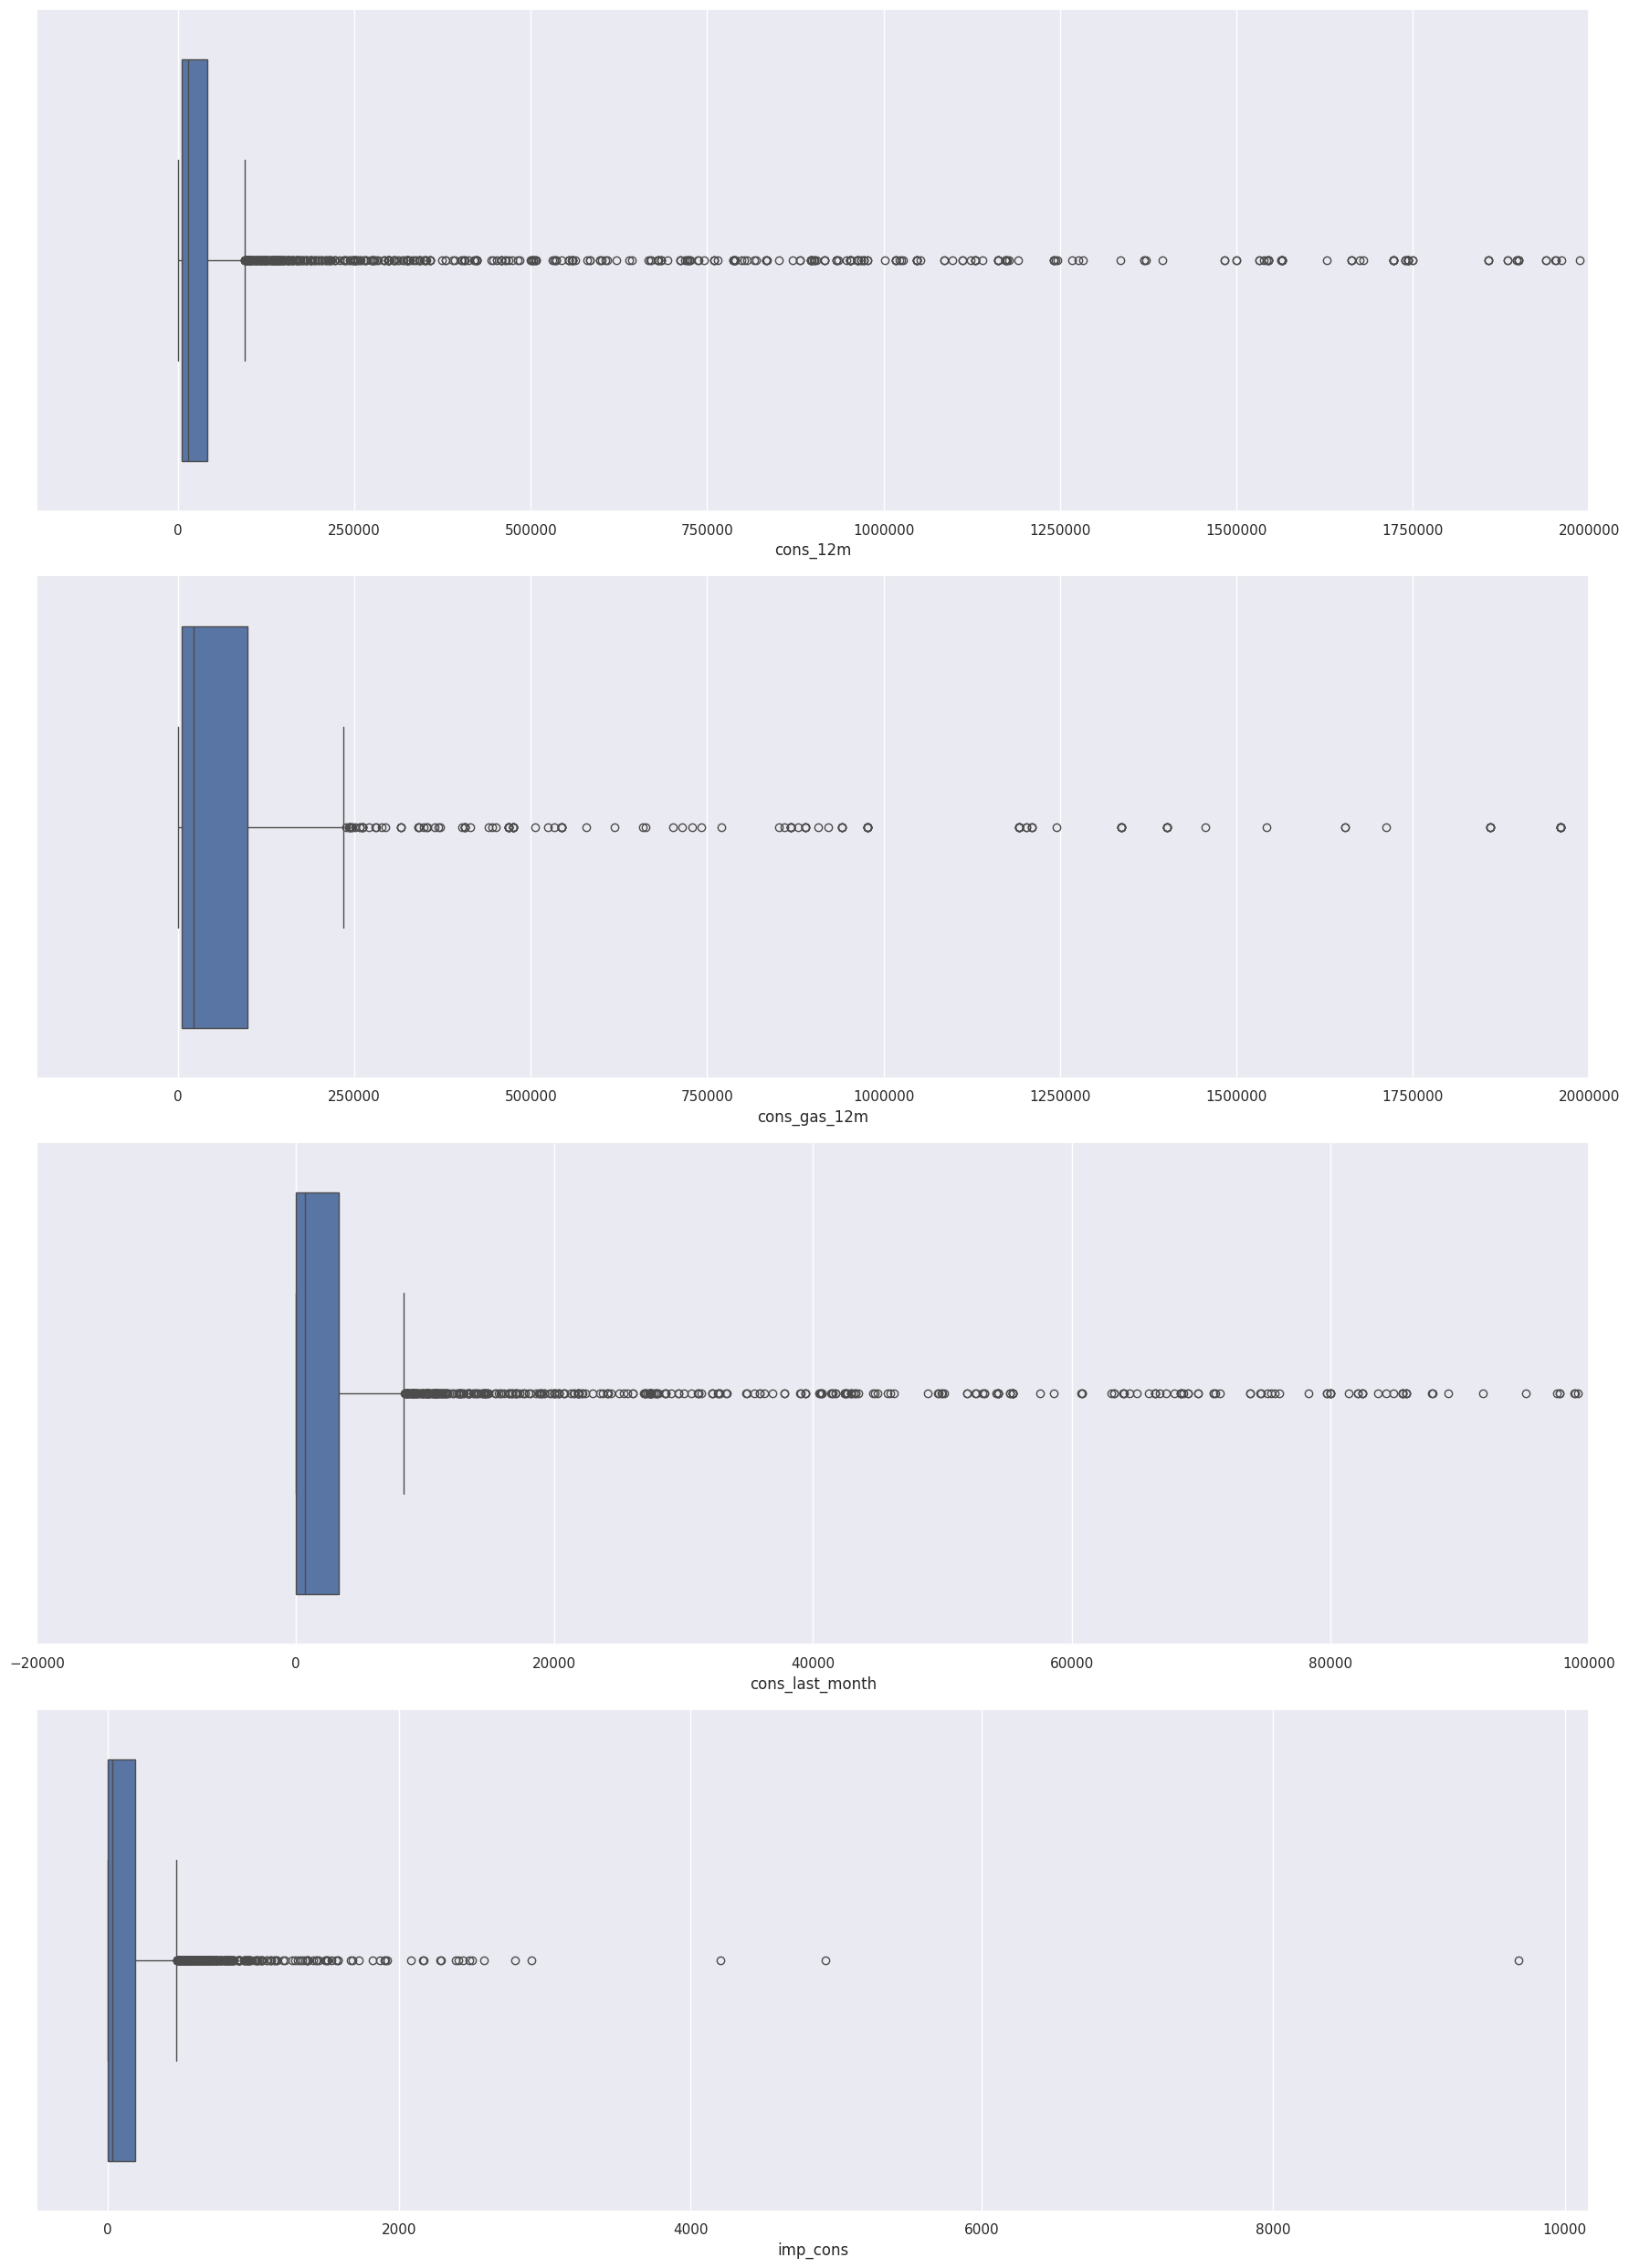

In [43]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

# Plot horizontal boxplots
sns.boxplot(x=consumption["cons_12m"], ax=axs[0])
sns.boxplot(x=consumption[consumption["has_gas"] == "t"]["cons_gas_12m"], ax=axs[1])
sns.boxplot(x=consumption["cons_last_month"], ax=axs[2])
sns.boxplot(x=consumption["imp_cons"], ax=axs[3])

# Set x-axis limits
axs[0].set_xlim(-200000, 2000000)
axs[1].set_xlim(-200000, 2000000)
axs[2].set_xlim(-20000, 100000)

# Format x-axis tick labels to remove scientific notation
for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')  # This should work now

plt.tight_layout()
plt.show()

We will deal with skewness and outliers during feature engineering in the next exercise.

### Forecast

In [44]:
forecast = client_df[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn"
    ]
]

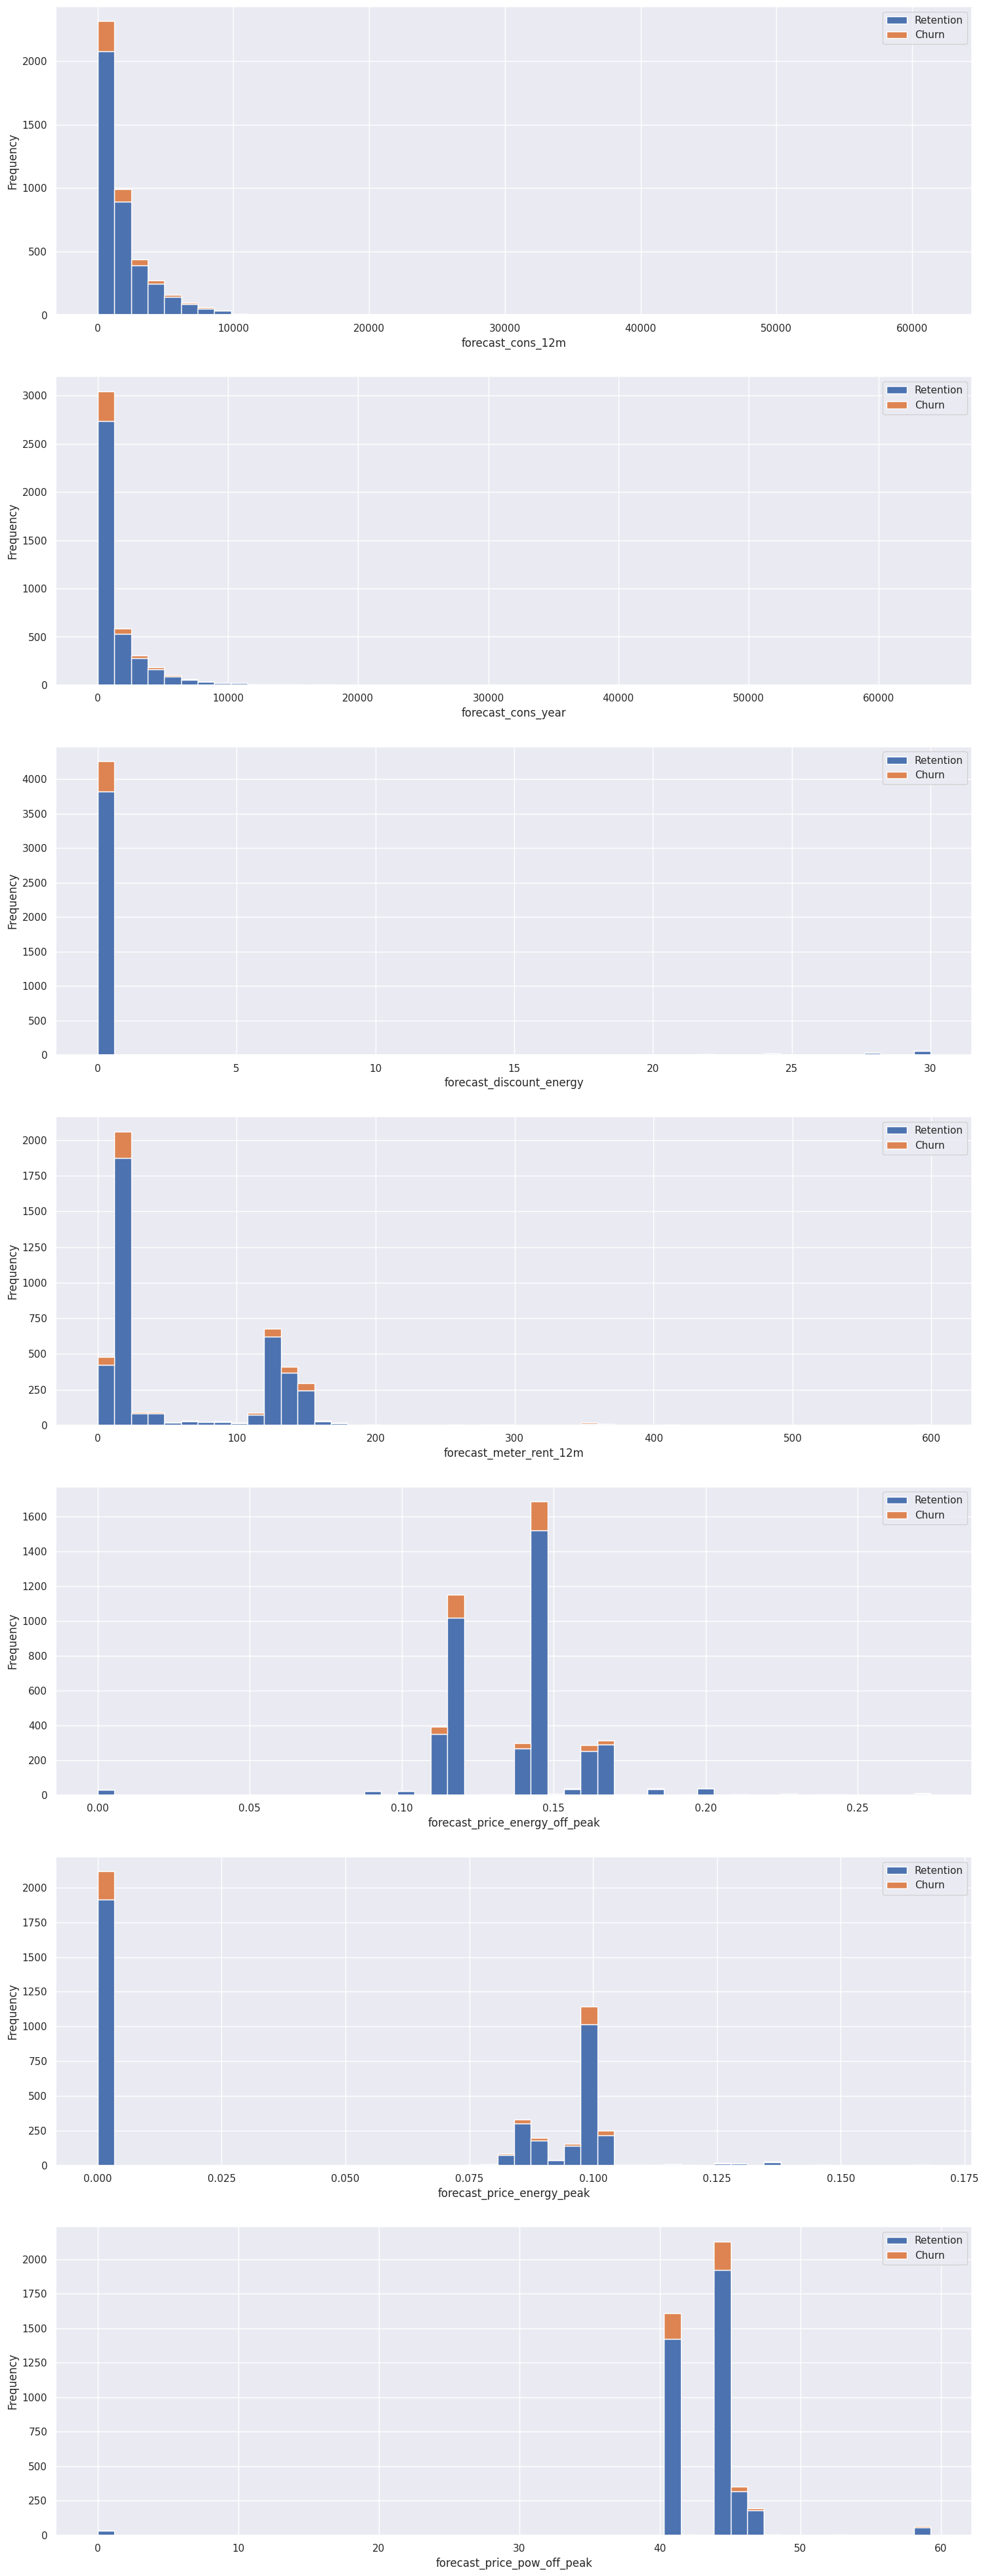

In [45]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

# Plot histogram
plot_distribution(client_df, "forecast_cons_12m", axs[0])
plot_distribution(client_df, "forecast_cons_year", axs[1])
plot_distribution(client_df, "forecast_discount_energy", axs[2])
plot_distribution(client_df, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_df, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_df, "forecast_price_energy_peak", axs[5])
plot_distribution(client_df, "forecast_price_pow_off_peak", axs[6])

Similarly to the consumption plots, we can observe that a lot of the variables are highly positively skewed, creating a very long tail for the higher values. We will make some transformations during the next exercise to correct for this skewness.

### Contract type

In [47]:
contract_type = client_df[['id', 'has_gas', 'churn']]
contract = contract_type.groupby(['has_gas', 'churn'])['id'].count().unstack(level=1).fillna(0)
contract_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

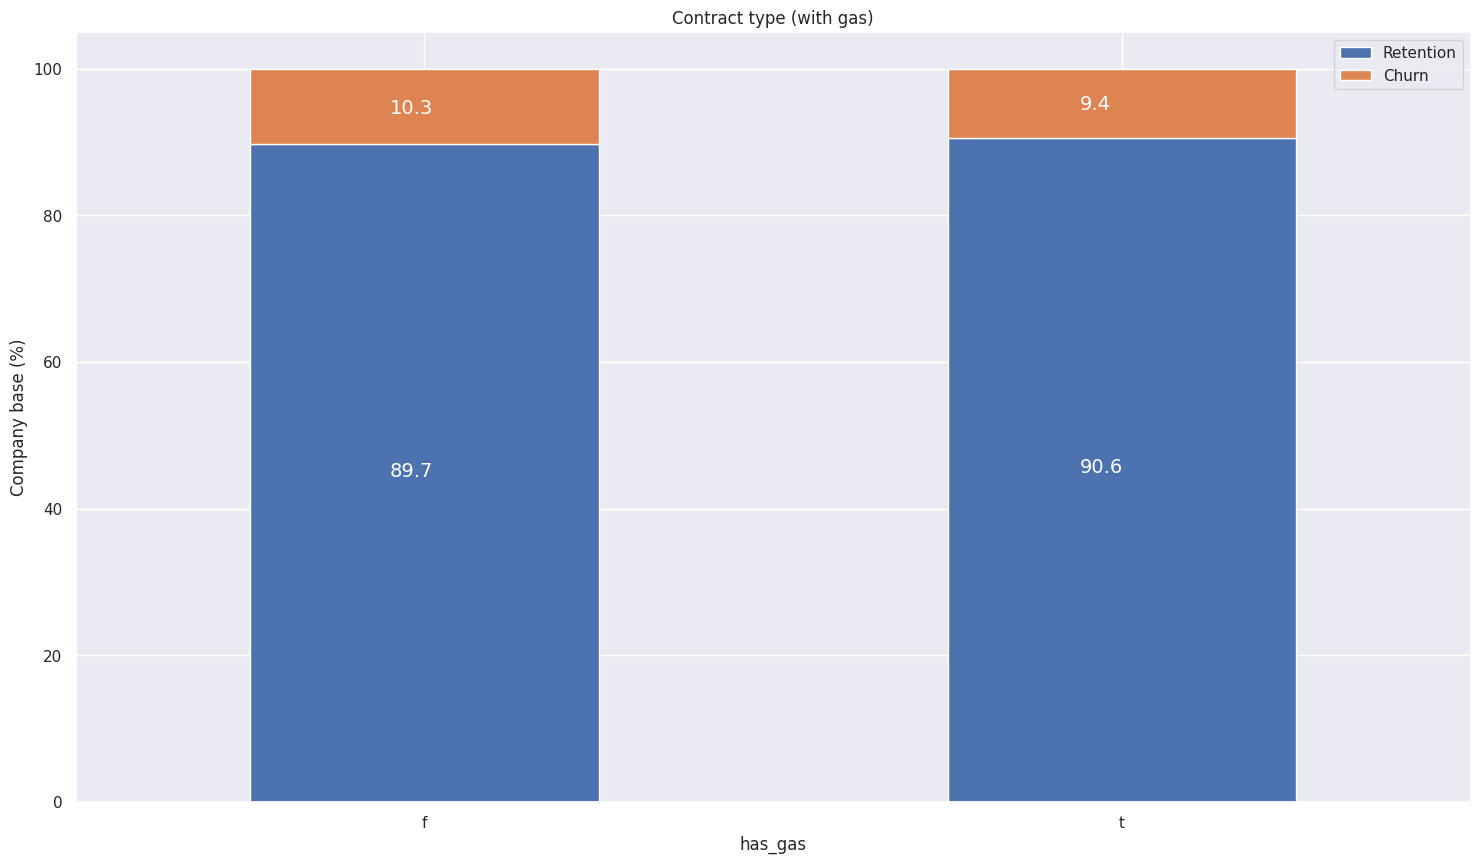

In [49]:
plot_stacked_bars(contract_percentage, 'Contract type (with gas)')

### Margins

In [50]:
margin = client_df[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

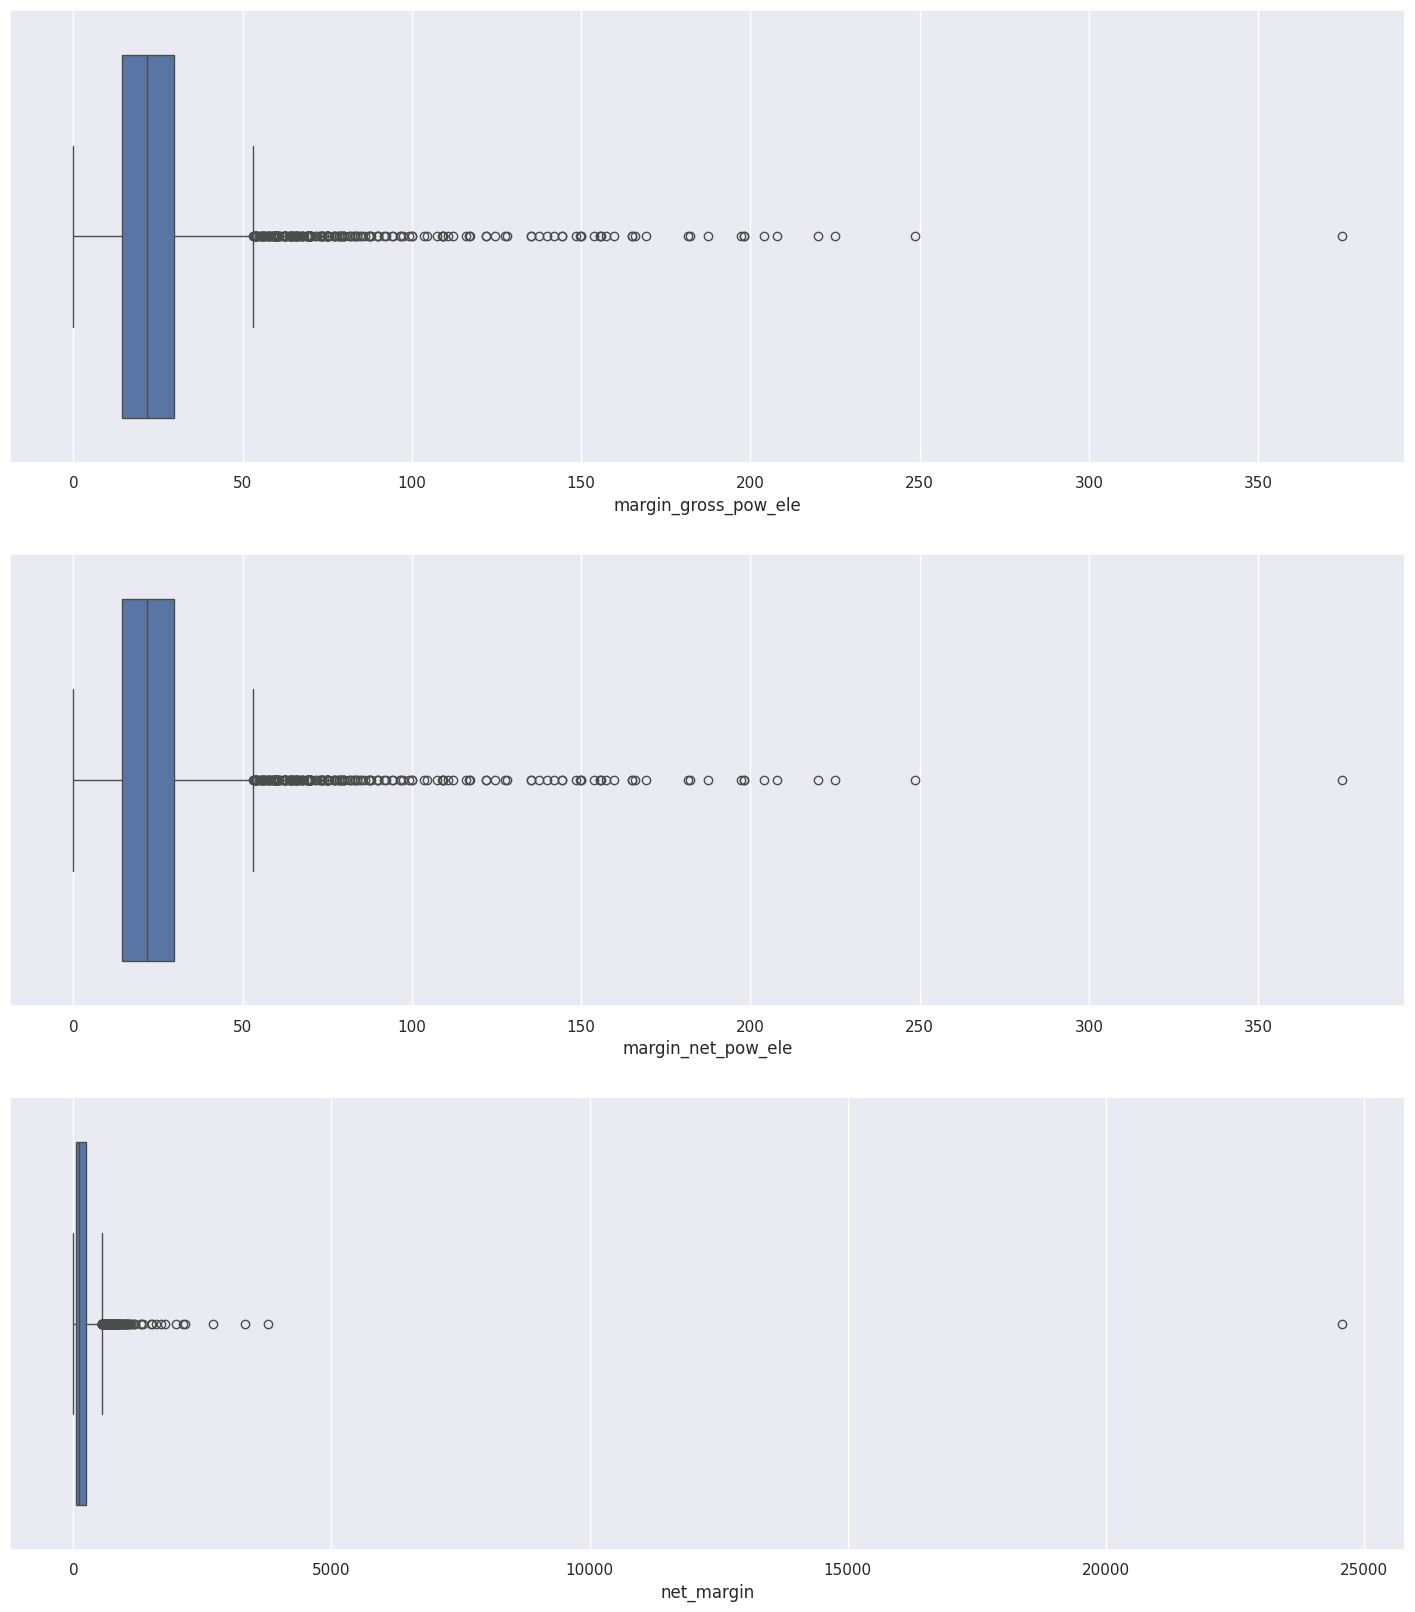

In [52]:
fig, axs = plt.subplots(nrows=3, figsize=(18,20))
# Plot histogram
sns.boxplot(x=margin["margin_gross_pow_ele"], ax=axs[0])
sns.boxplot(x=margin["margin_net_pow_ele"],ax=axs[1])
sns.boxplot(x=margin["net_margin"], ax=axs[2])
# Remove scientific notation
axs[0].ticklabel_format(style='plain', axis='x')
axs[1].ticklabel_format(style='plain', axis='x')
axs[2].ticklabel_format(style='plain', axis='x')
plt.show()

We can see some outliers here as well which we will deal with in the next exercise.

### Subscribed power

In [53]:
power = client_df[['id', 'pow_max', 'churn']]

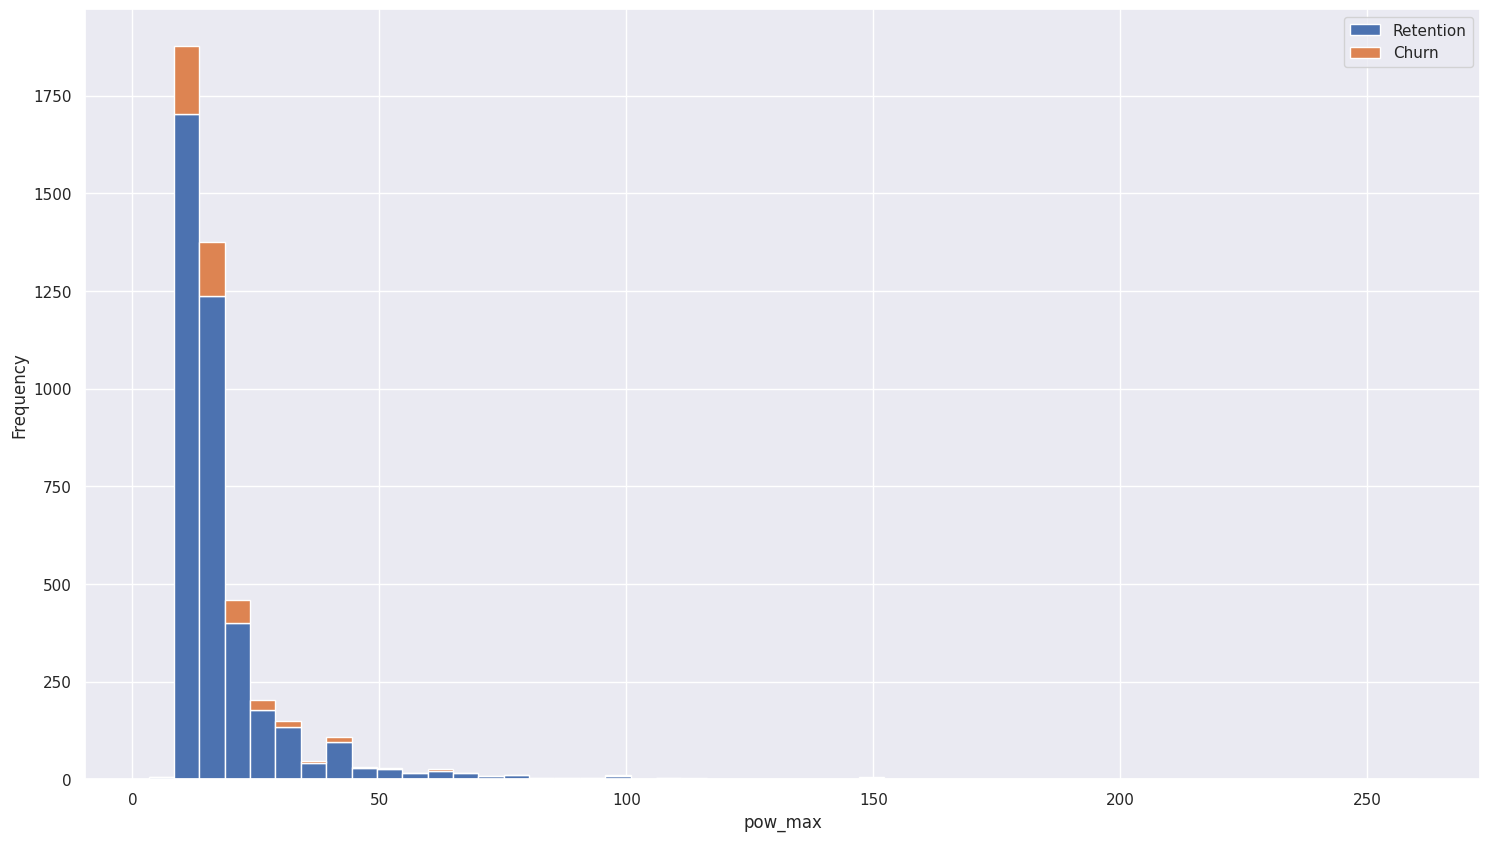

In [54]:
fig, axs = plt.subplots(nrows=1, figsize=(18, 10))
plot_distribution(power, 'pow_max', axs)

### Other columns

In [55]:
others = client_df[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]
products = others.groupby([others["nb_prod_act"],others["churn"]])["id"].count().unstack(level=1)
products_percentage = (products.div(products.sum(axis=1), axis=0)*100).sort_values(by=[1], ascending=False)

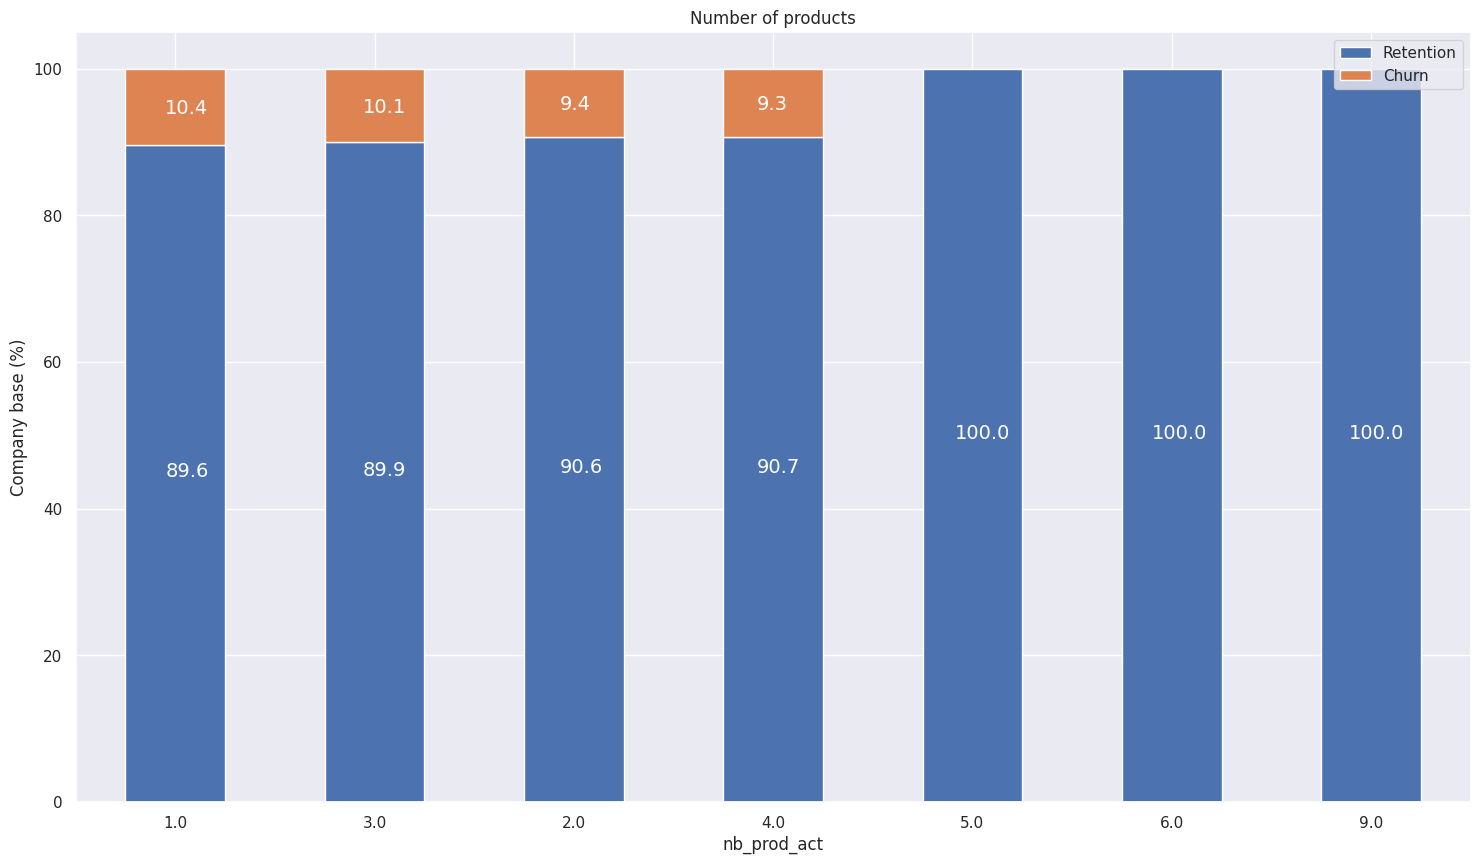

In [56]:
plot_stacked_bars(products_percentage, "Number of products")

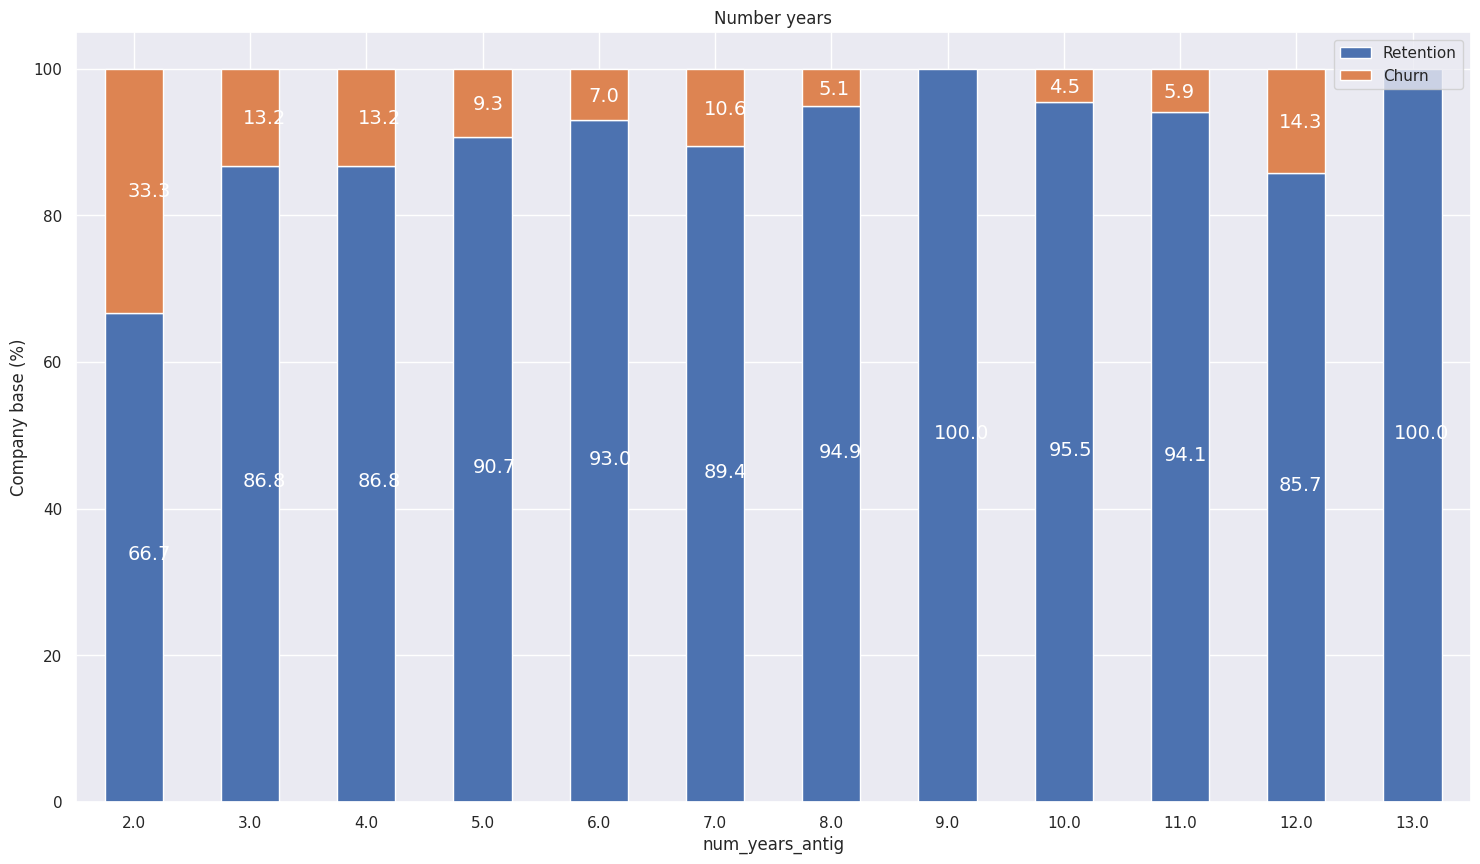

In [57]:
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

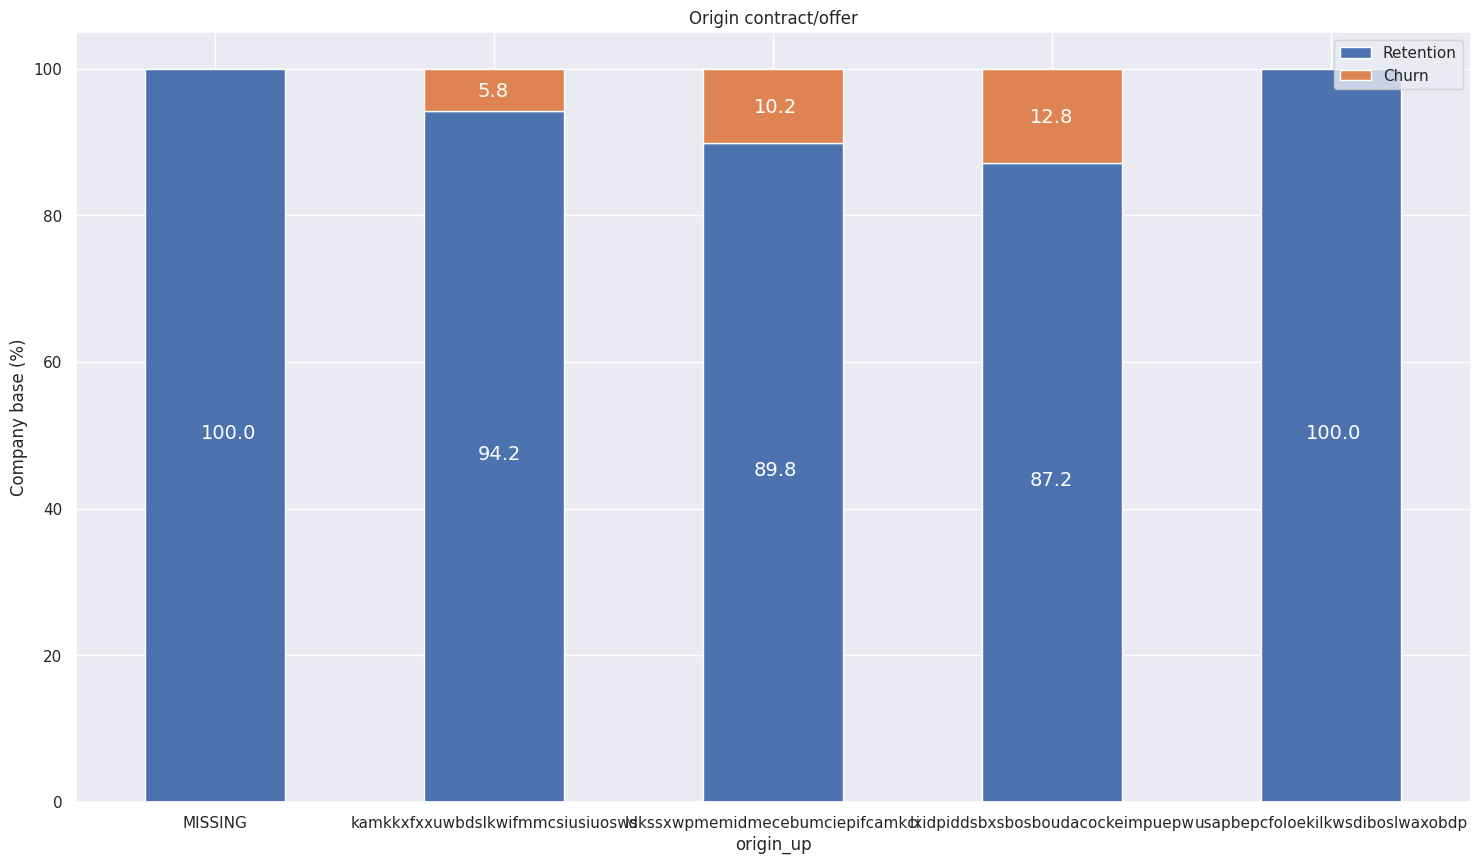

In [58]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")